## Aligning PACE and EMIT Data
Adapted from "Projecting & GeoTIFF" tutorial on OB.DAAC's [Help Hub][help-hub] and from LP.DAAC's [VITALS][vitals] "Working with EMIT L2A Reflectance and ECOSTRESS L2 LSTE" tutorial.

Author: Skye Caplan (NASA, SSAI), Erik Bolch (USGS)

Last updated: 03/04/2026

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/
[emit-data-access]: https://nasa.github.io/VITALS/python/Exploring_EMIT_L2A_RFL.html
[help-hub]: https://nasa.github.io/oceandata-notebooks/
[vitals]: https://nasa.github.io/VITALS/

<div class="alert alert-info" role="alert">

An [Earthdata Login][edl] account is required to access data from the NASA Earthdata system, including NASA PACE and EMIT data.

</div>

## Summary

This notebook will use the data downloaded from `01_Colocate_PACE_EMIT_data.ipynb` and the `rasterio` and `rioxarray` packages to put PACE and EMIT data on the same grid. We will use tools from LPDAAC's VITALS tutorials to orthorectify the EMIT data, and then place PACE and EMIT granules on a generalized grid using OCI's coarser resolution. We can then compare the data from the two sensors. These techniques will also be integral to our burn scar analysis in `03_NBR_with_PACE_EMIT.ipynb`.

## Learning Objectives

At the end of this notebook, you will know how to:
- Open and orthorectify an EMIT granule
- Take PACE L2 data from the instrument swath to a defined grid
- Downscale EMIT to PACE resolution
- Compare spectra between sensors

## Contents
1. [Setup](#1.-Setup)
2. [Gridding EMIT Data](#2.-Gridding-EMIT-Data)
3. [Projecting PACE Data onto a Defined Grid](#3.-Projecting-PACE-Data-onto-a-Defined-Grid)
4. [Aligning PACE and EMIT Grids ](#4.-Aligning-PACE-and-EMIT-Grids)
5. [Comparing the Data](#5.-Comparing-the-Data)


## 1. Setup

Begin by importing all of the packages used in this notebook.

In [1]:
import os
import rasterio 
import cf_xarray 
import cartopy
import xarray as xr 
import numpy as np 
import cartopy.crs as ccrs 
import rioxarray as rio

import matplotlib.pyplot as plt 
from rasterio.enums import Resampling
from rasterio.crs import CRS

os.chdir(os.path.abspath(os.path.join(get_ipython().starting_dir, os.pardir)))
from modules import pace_tools as pace
from modules import emit_tools as emit

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

def plot_features(ax, gridline_alpha=1):
    ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, linewidth=0.25, alpha=gridline_alpha)
    ax.coastlines(linewidth=0.5)
    ax.add_feature(cartopy.feature.OCEAN, edgecolor="w", linewidth=0.01)
    ax.add_feature(cartopy.feature.LAND, edgecolor="w", linewidth=0.01)
    ax.add_feature(cartopy.feature.LAKES, edgecolor="w", linewidth=0.01)

In the last notebook, we found and downloaded pre and post fire EMIT and PACE reflectance scenes to examine changes resulting from the January 2025 Southern California wildfires. We'll be using those files for the rest of the tutorials in this series, and so define their paths for this notebook in the cell below.

In [2]:
emit_paths = ["emit_pace/data/EMIT_L2A_RFL_001_20240825T173115_2423811_008.nc", # before
              "emit_pace/data/EMIT_L2A_RFL_001_20250324T220953_2508314_003.nc", # after
              "emit_pace/data/EMIT_L2A_MASK_001_20240825T173115_2423811_008.nc",
              "emit_pace/data/EMIT_L2A_MASK_001_20250324T220953_2508314_003.nc"] 
oci_paths = ["emit_pace/data/PACE_OCI.20241218T202231.L2.SFREFL.V3_1.nc",        # before
            "emit_pace/data/PACE_OCI.20250113T204049.L2.SFREFL.V3_1.nc"]        # after

If for some reason you need to download these files, uncomment and run the cell below.

In [3]:
# import earthaccess
# earthaccess.login()
# file_urls = [
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20240825T173115_2423811_008/EMIT_L2A_RFL_001_20240825T173115_2423811_008.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20240825T173115_2423811_008/EMIT_L2A_MASK_001_20240825T173115_2423811_008.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250324T220953_2508314_003/EMIT_L2A_RFL_001_20250324T220953_2508314_003.nc',
# 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/EMITL2ARFL.001/EMIT_L2A_RFL_001_20250324T220953_2508314_003/EMIT_L2A_MASK_001_20250324T220953_2508314_003.nc',
# 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20241218T202231.L2.SFREFL.V3_1.nc',
# 'https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/PACE_OCI.20250113T204049.L2.SFREFL.V3_1.nc'
# ]
# earthaccess.download(file_urls, local_path='emit_pace/data/')

Recall from the previous tutorial that these are Level-2 (L2) data. An important aspect of L2 data from any sensor is that that they are still in the instrument swath, meaning they are not on any predefined grid. Comparing the raw datasets, even doing so with two granules from the same sensor, would be inaccurate because the pixels do not represent the same location on the Earth. Especially because the eventual goal of this tutorial series is to compare data between sensors, we need to make sure our pixel centres have the same latitudes and longitudes - in other words, we have to grid our data.

To accomplish this gridding, we have to treat EMIT and PACE slightly differently. The EMIT L2A reflectance file comes with a geometry lookup table (GLT) in addition to the latitude and longitude of each pixel, which allows us to reproject the raw EMIT data onto a geographic grid. L2 Data from PACE does not have a GLT, so we will have to use another technique to project the data. 

The [VITALS][vitals] repository provides the `emit_tools` module which includes several functions to ease working with EMIT data. We'll use these first to orthorectify those data. More information can be found in the [EMIT-Data-Resources repository](https://github.com/nasa/EMIT-Data-Resources)

<div class="alert alert-warning" role="alert">

Need some text explaining the "pre" and "post" granules (a reminder of why we have multiple granules per sensor and not just one)

</div>

[vitals]: https://nasa.github.io/VITALS/

### 2. Gridding EMIT Data

The `emit_xarray` function in the `emit_tools` module is what will allow us to grid EMIT data. The `ortho=True` argument in the cell below tells the function to use the GLT to orthorectify the specific scene we feed it. Since we need both a "before" and "after" image to complete the burn analysis in the next tutorial(link when avail), we'll do this which each EMIT scene defined above.

We'll also mask out any fill values in the EMIT data by setting them to NaNs.

In [4]:
emit_pre = emit.emit_xarray(emit_paths[0], ortho=True)
emit_post = emit.emit_xarray(emit_paths[1], ortho=True)

emit_pre['reflectance'].data[emit_pre['reflectance'].data == -9999] = np.nan
emit_post['reflectance'].data[emit_post['reflectance'].data == -9999] = np.nan

EMIT data also comes with a quaity mask, which we will apply to the data. These also have to be orthorectified, and we can use the same function as above. Once we have the mask data, we can see which flags are provided in the mask. 

In [5]:
emit_pre_mask = emit.emit_xarray(emit_paths[2], ortho=True)
emit_post_mask = emit.emit_xarray(emit_paths[3], ortho=True)

emit_pre_mask['mask'].data[emit_pre_mask['mask'].data == -9999] = np.nan
emit_post_mask['mask'].data[emit_post_mask['mask'].data == -9999] = np.nan

emit_pre_mask.mask_bands.data.tolist()

['Cloud flag',
 'Cirrus flag',
 'Water flag',
 'Spacecraft Flag',
 'Dilated Cloud Flag',
 'AOD550',
 'H2O (g cm-2)',
 'Aggregate Flag']

The `Aggregate Flag` is a aggregation of the first 5 data quality flags listed above, but the dilated cloud flag is really aggressive at cloud masking. Since we have limited scenes during our timeframe we want to risk having some downstream cloud contamination in order to have a bit more data. To do this, we'll use the first 4 bands from the cloud mask.

In [6]:
selected_mask_bands = ['Cloud flag','Cirrus flag','Water flag','Spacecraft Flag']

# Select and Combine Bands
combined_emit_pre_mask = emit_pre_mask['mask'].sel(mask_bands=selected_mask_bands).any('mask_bands').astype(int)
combined_emit_post_mask = emit_post_mask['mask'].sel(mask_bands=selected_mask_bands).any('mask_bands').astype(int)

emit_pre["reflectance"].data[combined_emit_pre_mask.data == 1] = np.nan
emit_post["reflectance"].data[combined_emit_post_mask.data == 1] = np.nan

Now we can plot these data to verify they're gridded and masked. Note that for the scene used here the EMIT cloud screening process is not working well for water and some of the offshore clouds.

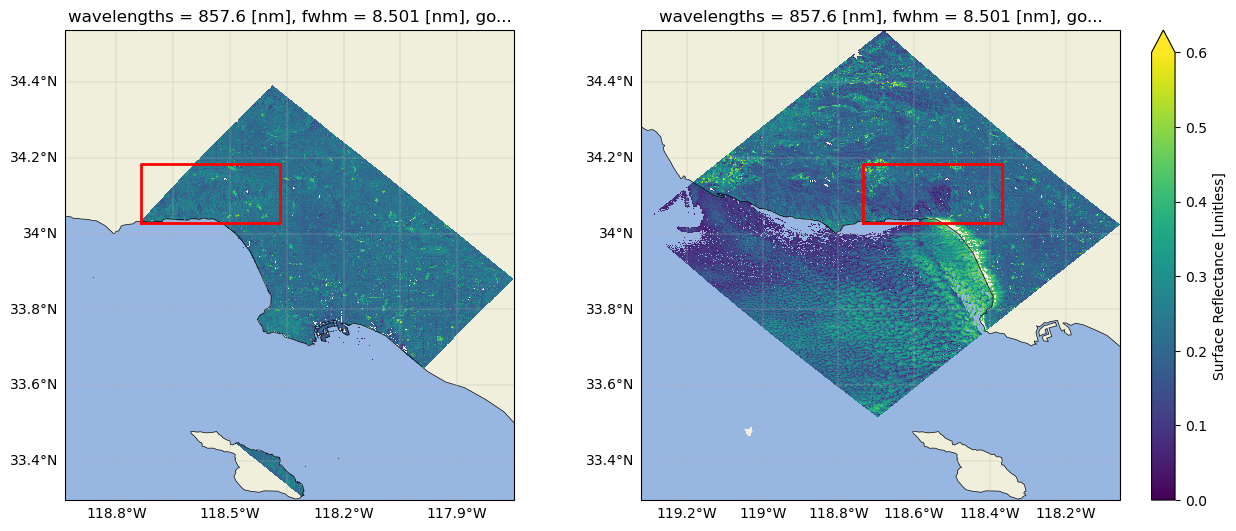

In [7]:
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
fig.tight_layout()
emit_pre["reflectance"].sel(wavelengths=860, method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6, add_colorbar=False)
emit_post["reflectance"].sel(wavelengths=860, method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6)
plot_features(ax[0])
plot_features(ax[1])
bbox = [-118.734, 34.027, -118.368, 34.183]  # [min_lon, min_lat, max_lon, max_lat]

# Plot as closed polygon
ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())
ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())          

plt.show()

We have geolocated and masked EMIT datasets now, but we still need to ensure these datasets are the same shape so that they can be used together for calculations. We'll use rioxarray's `reproject_match` function to match the post-fire granule's extent to the pre-fire, since the pre-fire granule covers more of our area of interest.

In [8]:
# Will likely exclude this (and the following two cells) because we will subset in the first notebook
#emit_post = emit_post.transpose("wavelengths", ...)
#emit_post = emit_post.rio.reproject_match(emit_pre)
#
#emit_post = emit_post.rename({"x":"longitude", "y":"latitude"})

We can print each dataset's shape to show they match and can be used later in calculations. 

In [9]:
# Swapped bc of the transpose above but not fixing bc we're taking these cells out
print(f"Pre-fire granule shape: {emit_pre.reflectance.shape}")
print(f"Post-fire granule shape: {emit_post.reflectance.shape}")

Pre-fire granule shape: (2020, 2184, 285)
Post-fire granule shape: (1887, 2334, 285)


Our EMIT data now match up to a physical location in space for each day of data, and can be used together in calculations later on. Let's make sure the same is true for PACE. 

### 3. Projecting PACE Data onto a Defined Grid
The `pace_tools` module provides a suite of functions for working with PACE OCI data, similar to the `emit_tools` module. We'll use the `open_l2` and `mask_l2` functions to accomplish the same steps for PACE as we did above with EMIT, with the key difference that the PACE data will not be gridded directly after opening the file. Due to aspects of `rasterio` and `rioxarray`, the packages we'll use to grid PACE data, as well as the fact that PACE's quality masks are included in the same L2 files as the reflectance data, all the masking must be done prior to the gridding step.

In [10]:
oci_pre = pace.open_l2(oci_paths[0])
oci_post = pace.open_l2(oci_paths[1])

oci_pre

<xarray.Dataset> Size: 1GB
Dimensions:        (number_of_lines: 1710, pixels_per_line: 1272,
                    wavelength_3d: 122)
Coordinates:
  * latitude       (number_of_lines, pixels_per_line) float32 9MB 15.29 ... 38.3
  * longitude      (number_of_lines, pixels_per_line) float32 9MB -125.7 ... ...
  * wavelength_3d  (wavelength_3d) float64 976B 346.0 351.0 ... 2.258e+03
Dimensions without coordinates: number_of_lines, pixels_per_line
Data variables:
    rhos           (number_of_lines, pixels_per_line, wavelength_3d) float32 1GB ...
    l2_flags       (number_of_lines, pixels_per_line) int32 9MB ...
Indexes:
  ┌ latitude   NDPointIndex (ScipyKDTreeAdapter)
  └ longitude
Attributes: (12/47)
    title:                             OCI Level-2 Data SFREFL
    product_name:                      PACE_OCI.20241218T202231.L2.SFREFL.V3_...
    processing_version:                3.1
    history:                           l2gen par=/data9/sdpsoper/vdc/vpu28/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -132.10988
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.0329703092575073
    geospatial_bounds:                 POLYGON ((-103.18229 38.30286, -132.10...

We can see that we have a dataset containing two variables: `rhos`, which are the surface reflectances, and `l2_flags`, which contain any masking information we may need. To mask the OCI data, all we need to know are the name(s) of the flags we want to use, and the `cf_xarray` package, which allows us to make use of those flags. For this example, we'll mask out clouds and water within the OCI scene using the "CLDICE" flag and the reverse of the "LAND" flag. A list of all possible flags can be found [here](https://oceancolor.gsfc.nasa.gov/resources/atbd/ocl2flags/). 

In [11]:
oci_pre = pace.mask_ds(oci_pre, flag=["CLDICE","LAND"], reverse=[False,True])
oci_post = pace.mask_ds(oci_post, flag=["CLDICE","LAND"], reverse=[False,True])

CLDICE mask applied
LAND mask applied
CLDICE mask applied
LAND mask applied


Now that our OCI data are masked, we can grid them. The `grid_data` function uses the 2D latitude and longitude arrays in the OCI reflectance dataset, a user-supplied resolution, and a coordinate reference system (CRS) to align the data onto a defined grid. Technically, you could tell the function to use any resolution, even one finer than the resolution at which the satellite collects data, and it would give you an output dataset. However, you want to make sure whatever parameters are passed to the function make sense for your analysis. In this case, we'll use a resolution that is approximately the resolution of PACE OCI data at nadir (taking into account its wide swath), 0.015 degrees (~1.67 km at the equator)

In [12]:
resolution = (0.015, 0.015)

oci_pre = pace.grid_data(oci_pre, resolution=resolution)
oci_post = pace.grid_data(oci_post, resolution=resolution)

We can make the same plot as EMIT's above to see what the gridded OCI data look like:

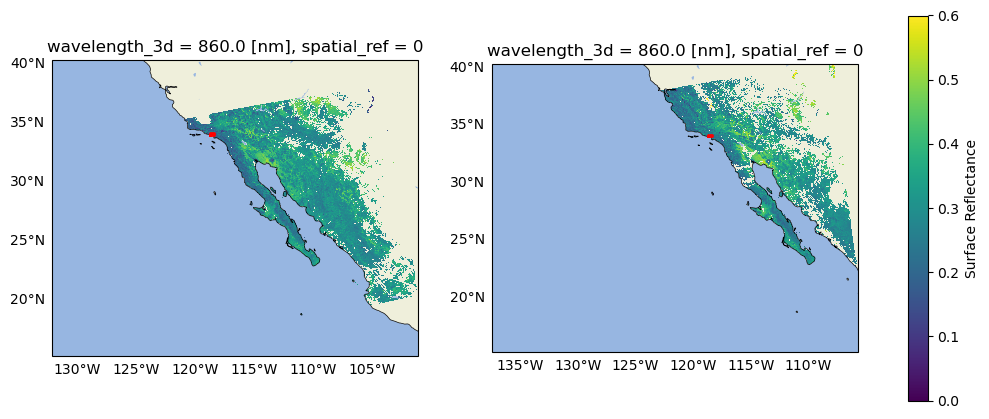

In [13]:
fig, ax = plt.subplots(1,2, figsize=(13,5),sharey=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
oci_pre["rhos"].sel(wavelength_3d=860, method="nearest").plot(ax=ax[0],vmin=0, vmax=0.6, add_colorbar=False)
im = oci_post["rhos"].sel(wavelength_3d=860, method="nearest").plot(ax=ax[1],vmin=0, vmax=0.6, add_colorbar=False)
fig.colorbar(im, ax=ax, label='Surface Reflectance')
plot_features(ax[0], gridline_alpha=0)
plot_features(ax[1], gridline_alpha=0)

# Plot as closed polygon
ax[0].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())
ax[1].plot([bbox[0], bbox[2], bbox[2], bbox[0], bbox[0]],
           [bbox[1], bbox[1], bbox[3], bbox[3], bbox[1]],
           color='red', linewidth=2, transform=ccrs.PlateCarree())  

plt.show()

Clearly, OCI covers a much wider area than EMIT does (but of course at a much coarser resolution). The goal of this tutorial series is to do a burn analysis of the LA area, so let's subset our gridded data (which will also shrink these pretty large datasets and make them more memory-manageable).

In [14]:
oci_pre_sub = oci_pre.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
oci_post_sub = oci_post.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})

emit_pre_sub = emit_pre.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})
emit_post_sub = emit_post.sel({"latitude":slice(bbox[3],bbox[1]), "longitude":slice(bbox[0],bbox[2])})

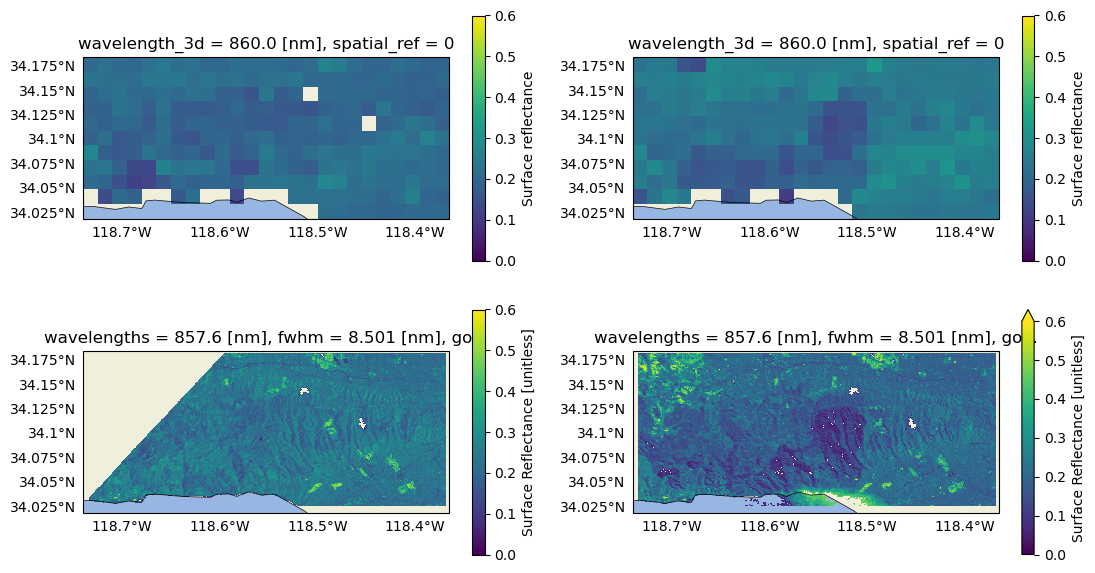

In [15]:
fig, ax = plt.subplots(2,2, figsize=(13,7),sharey=True, sharex=True, 
                       subplot_kw={"projection": ccrs.PlateCarree()})
oci_pre_sub["rhos"].sel(wavelength_3d=860, method="nearest").plot(ax=ax[0][0],vmin=0, vmax=0.6)
oci_post_sub["rhos"].sel(wavelength_3d=860, method="nearest").plot(ax=ax[0][1],vmin=0, vmax=0.6)
emit_pre_sub["reflectance"].sel(wavelengths=860, method="nearest").plot(ax=ax [1][0],vmin=0, vmax=0.6)
emit_post_sub["reflectance"].sel(wavelengths=860, method="nearest").plot(ax=ax[1][1],vmin=0, vmax=0.6)
plot_features(ax[0][0], gridline_alpha=0)
plot_features(ax[0][1], gridline_alpha=0)
plot_features(ax[1][0], gridline_alpha=0)
plot_features(ax[1][1], gridline_alpha=0)
plt.show()

In addition to a spatial subset, these datasets can be subset to include only the necessary wavelengths for the Normalized Burn Ratio (NBR) analysis that is the focus of the third tutorial in this series. NBR uses the NIR and SWIR to track changes in vegetation, so we can again use `xarray`'s `.sel()` functionality to grab only these bands. 

In [16]:
oci_pre_sub = oci_pre_sub.sel({"wavelength_3d":[870, 2131]}, method="nearest")
oci_post_sub = oci_post_sub.sel({"wavelength_3d":[870, 2131]}, method="nearest")

emit_pre_sub = emit_pre_sub.sel({"wavelengths":[870, 2131]}, method="nearest")
emit_post_sub = emit_post_sub.sel({"wavelengths":[870, 2131]}, method="nearest")

Let's export our datasets so we can continue working with them without repeating these steps each time.

In [19]:
oci_pre_sub.to_netcdf("emit_pace/subset_data/oci_prefire.nc")
oci_post_sub.to_netcdf("emit_pace/subset_data/oci_postfire.nc")

emit_pre_sub.to_netcdf("emit_pace/subset_data/emit_prefire.nc")
emit_post_sub.to_netcdf("emit_pace/subset_data/emit_postfire.nc")

### 4. Aligning PACE and EMIT Grids 
The case study example in `03_NBR_with_PACE_EMIT.ipynb` doesn't require PACE and EMIT to be on the same grid as we are going to illustrate the complimentary nature of the instruments' temporal, spatial, and spectral resolutions. However, there may be times when you want to align grids (and therefore, resolutions) between these two instruments. We'll take our pre-fire subsets from OCI and EMIT and demonstrate how to align their grids below using a modified version of the `grid_data` function in the `pace_tools` module. 

If we zoom in close enough, we can see the difference in pixel size between PACE and EMIT:

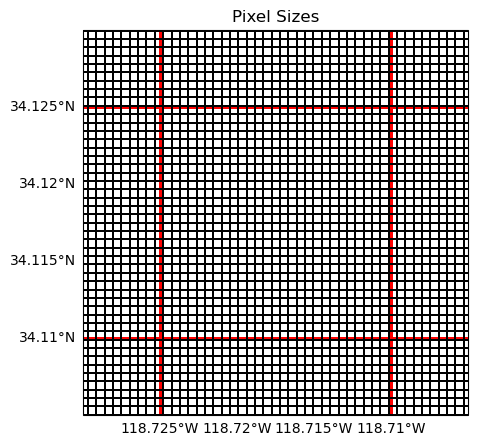

In [26]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
oci_pre_sub.rhos.sel({"wavelength_3d":860}, method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", transform=ccrs.PlateCarree(),linewidth=2, edgecolors="red", add_colorbar=False)
emit_pre_sub.reflectance.sel({"wavelengths":860}, method="nearest").plot(vmin=0, vmax=1, cmap="viridis", transform=ccrs.PlateCarree(),  linewidth=0.05, edgecolors="k", add_colorbar=False, alpha=1)
ax.set_extent([-118.73, -118.705, 34.105, 34.13])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Sizes")
plt.show()

The red outlines above show the boundaries for PACE pixels and the grey lines similarly delineate EMIT pixels within the same region. The EMIT resolution is significantly finer, but as previously discussed has more sparse observations. Additionally, we can see that the EMIT and PACE grids are not spatially aligned. We can use the `grid_data` function to regrid and resample either dataset, coarsening EMIT to match PACE's resolution, or sharpening (interpolating) PACE onto EMIT's finer grid. It's important to note that sharpening the data does not increase the information content of the data - in other words, we will just be duplicating existing values to fill a larger quantity of pixels covering the same spatial extent. This sharpening approach is often used to prepare a consistent grid for analysis when the goal is to preserve fine-resolution details from the higher resolution dataset. A coarsening approach is often selected when the goal is to reduce noise in high resolution imagery or reduce file sizes for large scale regional and global studies.

Let's regrid the PACE data to a finer resolution and see what this means. We'll use the Affine transform from the EMIT data to grab its spatial resolution, and we'll use it's CRS as our destination CRS. Note that both of these datasets use EPSG 4326, so the defaults in the `grid_data` function would be fine, but we'll set them explicitly to be thorough.

In [31]:
oci_finer = pace.grid_data(src=oci_pre_sub, 
                           dst_transform=emit_pre_sub.rio.transform())

We can plot the pixel boundaries again to check that our granules are at the same resolution now.

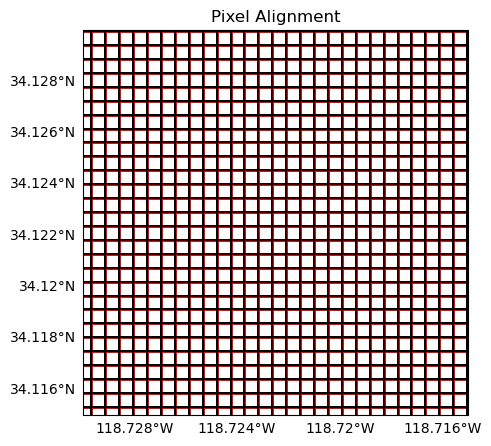

In [34]:
fig, ax = plt.subplots(figsize=(13,5), subplot_kw=dict(projection=ccrs.PlateCarree()))
oci_finer.rhos.sel({"wavelength_3d":860}, method="nearest").plot(vmin=-1, vmax=0, cmap="Greys_r", transform=ccrs.PlateCarree(),linewidth=2, edgecolors="red", add_colorbar=False)
emit_pre_sub.reflectance.sel({"wavelengths":860}, method="nearest").plot(vmin=0, vmax=1, cmap="viridis", transform=ccrs.PlateCarree(),  linewidth=0.05, edgecolors="k", add_colorbar=False, alpha=1)
ax.set_extent([-118.73, -118.715, 34.115, 34.13])
ax.gridlines(draw_labels={"left": "y", "bottom": "x"}, alpha=0.0)
ax.set_title("Pixel Alignment")
plt.show()

We can see the pixels are aligned, which would allow for spectral comparisons between the two datasets. A similar method could be used to coarsen the EMIT data to PACE's resolution. 

<div class="alert alert-info" role="alert">

You have completed the second notebook in the PACE+EMIT series. We suggest moving on to the third notebook, 03_NBR_with_PACE_EMIT.ipynb, which uses the data we aligned here to conduct a burn analysis on wildfires which occurred in Southern California in January 2025. 

</div>